# PJM LMP Market Forecasting and Analytics

This notebook builds a clean, industry-style energy market analytics pipeline using PJM AEP LMP data, load data, and weather data. The goal is to create a reproducible market forecasting workflow with robust feature engineering, XGBoost forecasting, spike risk modeling, and operational interpretation.

## 1. Data Pipeline

Load, clean, and validate the PJM AEP LMP dataset. Then merge the market data with the cleaned hourly load/weather base dataset to create a master market analytics table.

The PJM datetime field is expressed in Eastern Prevailing Time (EPT). This means the fall-back transition at 2024-11-03 produces two distinct 1 AM records, which is expected and should be retained rather than deduplicated.

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_absolute_error, mean_squared_error
from xgboost import XGBClassifier, XGBRegressor

sns.set_theme(style='whitegrid')
pd.options.display.max_columns = 100
pd.options.display.width = 120

In [103]:
def load_clean_lmp_data(paths):
    lmp_frames = []
    for path in paths:
        df = pd.read_csv(path)
        lmp_frames.append(df)
    market_df = pd.concat(lmp_frames, ignore_index=True)

    market_df = market_df.rename(columns={
        'datetime_beginning_ept': 'datetime',
        'total_lmp_da': 'total_lmp_day_ahead',
        'total_lmp_rt': 'total_lmp_real_time',
        'congestion_price_da': 'congestion_price_day_ahead',
        'congestion_price_rt': 'congestion_price_real_time',
        'marginal_loss_price_da': 'marginal_loss_price_day_ahead',
        'marginal_loss_price_rt': 'marginal_loss_price_real_time'
    })

    market_df['datetime'] = pd.to_datetime(market_df['datetime'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
    market_df = market_df.sort_values('datetime').reset_index(drop=True)
    keep_cols = [
        'datetime',
        'total_lmp_day_ahead',
        'total_lmp_real_time',
        'congestion_price_day_ahead',
        'congestion_price_real_time',
        'marginal_loss_price_day_ahead',
        'marginal_loss_price_real_time'
    ]
    market_df = market_df[keep_cols].copy()
    return market_df

def validate_hourly_index(df, datetime_col='datetime'):
    duplicates = df[datetime_col].duplicated().sum()
    expected_index = pd.date_range(df[datetime_col].min(), df[datetime_col].max(), freq='H')
    missing_times = expected_index.difference(df[datetime_col])
    return duplicates, missing_times

In [104]:
lmp_paths = [
    '../data/rt_da_monthly_lmps_2024.csv',
    '../data/rt_da_monthly_lmps_2025.csv'
] 
market_df = load_clean_lmp_data(lmp_paths)

print('LMP rows:', len(market_df))
print('LMP columns:', market_df.columns.tolist())
print('Missing datetime rows:', market_df['datetime'].isna().sum())
duplicates, missing_times = validate_hourly_index(market_df)
print('Duplicate datetimes:', duplicates)
print('Missing timestamp count:', len(missing_times))
if duplicates > 0:
    print('Note: Duplicate 1 AM entries on 2024-11-03 correspond to the DST fall-back transition in EPT. Both entries are expected and retained.')
if len(missing_times) > 0:
    print('Missing ranges sample:', missing_times[:10])
    if pd.Timestamp('2024-03-10 02:00:00') in missing_times or pd.Timestamp('2025-03-09 02:00:00') in missing_times:
        print('Note: Missing 02:00 on 2024-03-10 and 2025-03-09 corresponds to the DST spring-forward transition in EPT.')

print('Summary statistics for cleaned LMP dataset:')
print(market_df.describe().T)

LMP rows: 11663
LMP columns: ['datetime', 'total_lmp_day_ahead', 'total_lmp_real_time', 'congestion_price_day_ahead', 'congestion_price_real_time', 'marginal_loss_price_day_ahead', 'marginal_loss_price_real_time']
Missing datetime rows: 0
Duplicate datetimes: 1
Missing timestamp count: 2
Note: Duplicate 1 AM entries on 2024-11-03 correspond to the DST fall-back transition in EPT. Both entries are expected and retained.
Missing ranges sample: DatetimeIndex(['2024-03-10 02:00:00', '2025-03-09 02:00:00'], dtype='datetime64[ns]', freq=None)
Note: Missing 02:00 on 2024-03-10 and 2025-03-09 corresponds to the DST spring-forward transition in EPT.
Summary statistics for cleaned LMP dataset:
                                 count                           mean                  min                  25%  \
datetime                         11663  2024-08-30 23:35:54.505701888  2024-01-01 00:00:00  2024-05-01 12:30:00   
total_lmp_day_ahead            11663.0                      35.420864        

/var/folders/yd/h0rh3srn2634qw945z8lpjkr0000gq/T/ipykernel_38906/1912570464.py:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  expected_index = pd.date_range(df[datetime_col].min(), df[datetime_col].max(), freq='H')


In [105]:
market_df

,datetime,total_lmp_day_ahead,total_lmp_real_time,congestion_price_day_ahead,congestion_price_real_time,marginal_loss_price_day_ahead,marginal_loss_price_real_time
0,2024-01-01 00:00:00,19.695037,31.308987,0.401594,0.418620,-0.106557,-0.244633
1,2024-01-01 01:00:00,19.517617,19.872421,0.482113,0.289292,-0.114496,-0.141871
2,2024-01-01 02:00:00,19.230987,17.341847,0.580922,0.332354,-0.129935,-0.107174
3,2024-01-01 03:00:00,19.318076,19.600685,0.618010,0.422335,-0.159934,-0.084150
4,2024-01-01 04:00:00,20.054035,16.940858,0.589824,0.134794,-0.135789,-0.091435
...,...,...,...,...,...,...,...
11658,2025-04-30 19:00:00,84.851251,62.717283,-5.661386,-63.382919,-1.967363,-2.360631
11659,2025-04-30 20:00:00,85.084750,49.992789,-4.239189,-25.192264,-1.526061,-1.295780
11660,2025-04-30 21:00:00,54.612657,35.093171,-0.915975,-2.850176,-0.831368,-0.342486
11661,2025-04-30 22:00:00,37.880651,27.906064,-0.494062,0.589402,-0.575287,-0.054171


## Market Feature Engineering

Generate pricing spread features, congestion share metrics, and market spike labels. These features help capture price formation dynamics between day-ahead and real-time markets.

In [106]:
def engineer_market_features(df):
    df = df.copy()
    df['rt_da_spread'] = df['total_lmp_real_time'] - df['total_lmp_day_ahead']
    df['congestion_share_da'] = df['congestion_price_day_ahead'] / df['total_lmp_day_ahead']
    df['congestion_share_rt'] = df['congestion_price_real_time'] / df['total_lmp_real_time']
    df[['congestion_share_da', 'congestion_share_rt']] = df[['congestion_share_da', 'congestion_share_rt']].replace([np.inf, -np.inf], np.nan)

    da_threshold = df['total_lmp_day_ahead'].quantile(0.95)
    rt_threshold = df['total_lmp_real_time'].quantile(0.95)
    df['da_price_spike'] = (df['total_lmp_day_ahead'] > da_threshold).astype(int)
    df['rt_price_spike'] = (df['total_lmp_real_time'] > rt_threshold).astype(int)

    print(f'DA spike threshold: {da_threshold:.2f}, spike count: {df["da_price_spike"].sum()}')
    print(f'RT spike threshold: {rt_threshold:.2f}, spike count: {df["rt_price_spike"].sum()}')
    return df

market_df = engineer_market_features(market_df)
print('After market feature engineering:')
print(market_df[['rt_da_spread', 'congestion_share_da', 'congestion_share_rt', 'da_price_spike', 'rt_price_spike']].describe().T)

DA spike threshold: 69.88, spike count: 584
RT spike threshold: 76.96, spike count: 584
After market feature engineering:
                       count      mean        std         min       25%       50%       75%         max
rt_da_spread         11663.0 -0.104728  20.548842 -202.362508 -5.966870 -1.899274  2.608404  794.381273
congestion_share_da  11663.0  0.018666   0.081828   -1.214736  0.003557  0.024553  0.052208    0.281034
congestion_share_rt  11663.0  0.013694   0.163806   -3.033574  0.000548  0.019066  0.063235    0.577675
da_price_spike       11663.0  0.050073   0.218105    0.000000  0.000000  0.000000  0.000000    1.000000
rt_price_spike       11663.0  0.050073   0.218105    0.000000  0.000000  0.000000  0.000000    1.000000


## Merge with Load and Weather Data

Combine the cleaned market dataset with the hourly load/weather base dataset to create a master market analytics table. This merge aligns LMP, load, and temperature on the same hourly timestamps.

In [107]:
load_weather_path = '../data/aep_load_weather_hourly_dataset.csv'
load_weather_df = pd.read_csv(load_weather_path)
load_weather_df['datetime'] = pd.to_datetime(load_weather_df['datetime'], errors='coerce')
load_weather_df = load_weather_df.sort_values('datetime').reset_index(drop=True)

print('Load/weather rows:', len(load_weather_df))
print(load_weather_df.head(2).to_string())

master_df = market_df.merge(load_weather_df[['datetime', 'load_mw', 'temperature_2m']], on='datetime', how='inner')
print('Merged master rows:', len(master_df))
print(master_df[['datetime', 'total_lmp_day_ahead', 'load_mw', 'temperature_2m']].head(3).to_string())

Load/weather rows: 11662
             datetime    load_mw  temperature_2m  sin_hour  cos_hour
0 2024-01-01 00:00:00  13510.539            -0.4  0.000000  1.000000
1 2024-01-01 01:00:00  13392.585            -0.6  0.258819  0.965926
Merged master rows: 11663
             datetime  total_lmp_day_ahead    load_mw  temperature_2m
0 2024-01-01 00:00:00            19.695037  13510.539            -0.4
1 2024-01-01 01:00:00            19.517617  13392.585            -0.6
2 2024-01-01 02:00:00            19.230987  13317.742            -0.6


In [108]:
master_df

,datetime,total_lmp_day_ahead,total_lmp_real_time,congestion_price_day_ahead,congestion_price_real_time,marginal_loss_price_day_ahead,marginal_loss_price_real_time,rt_da_spread,congestion_share_da,congestion_share_rt,da_price_spike,rt_price_spike,load_mw,temperature_2m
0,2024-01-01 00:00:00,19.695037,31.308987,0.401594,0.418620,-0.106557,-0.244633,11.613950,0.020391,0.013371,0,0,13510.539,-0.4
1,2024-01-01 01:00:00,19.517617,19.872421,0.482113,0.289292,-0.114496,-0.141871,0.354804,0.024701,0.014557,0,0,13392.585,-0.6
2,2024-01-01 02:00:00,19.230987,17.341847,0.580922,0.332354,-0.129935,-0.107174,-1.889140,0.030208,0.019165,0,0,13317.742,-0.6
3,2024-01-01 03:00:00,19.318076,19.600685,0.618010,0.422335,-0.159934,-0.084150,0.282609,0.031991,0.021547,0,0,13242.742,-0.6
4,2024-01-01 04:00:00,20.054035,16.940858,0.589824,0.134794,-0.135789,-0.091435,-3.113177,0.029412,0.007957,0,0,13392.619,-0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11658,2025-04-30 19:00:00,84.851251,62.717283,-5.661386,-63.382919,-1.967363,-2.360631,-22.133968,-0.066721,-1.010613,1,0,15471.120,21.4
11659,2025-04-30 20:00:00,85.084750,49.992789,-4.239189,-25.192264,-1.526061,-1.295780,-35.091961,-0.049823,-0.503918,1,0,15415.869,19.9
11660,2025-04-30 21:00:00,54.612657,35.093171,-0.915975,-2.850176,-0.831368,-0.342486,-19.519486,-0.016772,-0.081217,0,0,15211.573,18.2
11661,2025-04-30 22:00:00,37.880651,27.906064,-0.494062,0.589402,-0.575287,-0.054171,-9.974587,-0.013043,0.021121,0,0,14197.577,17.4


## Forecast Feature Engineering

Create calendar, cyclical, lag, and rolling features for price forecasting. All lag and rolling features are shifted to use only past information, avoiding data leakage.

In [109]:
def engineer_forecasting_features(df):
    df = df.copy()
    df['hour'] = df['datetime'].dt.hour
    df['dayofweek'] = df['datetime'].dt.dayofweek
    df['month'] = df['datetime'].dt.month
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)

    for var in ['load_mw', 'total_lmp_day_ahead']:
        for lag in [1, 24, 168]:
            df[f'{var}_lag_{lag}'] = df[var].shift(lag)

    df['load_mw_rolling_mean_24'] = df['load_mw'].shift(1).rolling(window=24).mean()
    df['load_mw_rolling_std_24'] = df['load_mw'].shift(1).rolling(window=24).std()
    df['da_lmp_rolling_mean_24'] = df['total_lmp_day_ahead'].shift(1).rolling(window=24).mean()
    df['da_lmp_rolling_std_24'] = df['total_lmp_day_ahead'].shift(1).rolling(window=24).std()
    df['congestion_share_da_lag_1'] = df['congestion_share_da'].shift(1)

    drop_cols = [
        'load_mw_lag_1', 'load_mw_lag_24', 'load_mw_lag_168',
        'total_lmp_day_ahead_lag_1', 'total_lmp_day_ahead_lag_24', 'total_lmp_day_ahead_lag_168',
        'load_mw_rolling_mean_24', 'load_mw_rolling_std_24',
        'da_lmp_rolling_mean_24', 'da_lmp_rolling_std_24',
        'congestion_share_da_lag_1'
    ]
    df = df.dropna(subset=drop_cols).reset_index(drop=True)
    return df

master_df = engineer_forecasting_features(master_df)
print('Master dataset after feature engineering rows:', len(master_df))
print(master_df[['datetime', 'hour', 'load_mw_lag_1', 'total_lmp_day_ahead_lag_1', 'da_lmp_rolling_mean_24', 'da_price_spike']].head(3).to_string())

# Define targets for next-hour forecasting
master_df['target_da_lmp_next_hour'] = master_df['total_lmp_day_ahead'].shift(-1)
master_df['target_da_spike_next_hour'] = master_df['da_price_spike'].shift(-1)

Master dataset after feature engineering rows: 11495
             datetime  hour  load_mw_lag_1  total_lmp_day_ahead_lag_1  da_lmp_rolling_mean_24  da_price_spike
0 2024-01-08 00:00:00     0      14832.815                  25.542823               26.017351               0
1 2024-01-08 01:00:00     1      14619.841                  23.131838               25.915061               0
2 2024-01-08 02:00:00     2      14607.270                  22.620641               25.887662               0


## Forecast Modeling

Train time-series-safe XGBoost models for the next-hour day-ahead price forecast and the next-hour day-ahead price spike classification. The split is based on chronology, not random sampling.

In [110]:
def time_based_split(df, fraction=0.8):
    split_loc = int(len(df) * fraction)
    train_df = df.iloc[:split_loc].copy()
    test_df = df.iloc[split_loc:].copy()
    return train_df, test_df

# Define targets for next-hour forecasting
master_df['target_da_lmp_next_hour'] = master_df['total_lmp_day_ahead'].shift(-1)
master_df['target_da_spike_next_hour'] = master_df['da_price_spike'].shift(-1)

regression_features = [
    'hour', 'dayofweek', 'month', 'is_weekend', 'sin_hour', 'cos_hour',
    'temperature_2m', 'load_mw',
    'load_mw_lag_1', 'load_mw_lag_24', 'load_mw_lag_168',
    'total_lmp_day_ahead_lag_1', 'total_lmp_day_ahead_lag_24', 'total_lmp_day_ahead_lag_168',
    'load_mw_rolling_mean_24', 'load_mw_rolling_std_24',
    'da_lmp_rolling_mean_24', 'da_lmp_rolling_std_24',
    'congestion_share_da_lag_1'  # Lagged to avoid leakage
]

# Drop NA in features and targets for clean modeling
master_df = master_df.dropna(
    subset=regression_features + ['target_da_lmp_next_hour', 'target_da_spike_next_hour']
).reset_index(drop=True)

train_df, test_df = time_based_split(master_df, fraction=0.8)
print('Train rows:', len(train_df))
print('Test rows:', len(test_df))
print('Train range:', train_df['datetime'].min(), 'to', train_df['datetime'].max())
print('Test range:', test_df['datetime'].min(), 'to', test_df['datetime'].max())

X_train_reg = train_df[regression_features]
X_test_reg = test_df[regression_features]
y_train_reg = train_df['target_da_lmp_next_hour']  # Predicting next-hour DA LMP
y_test_reg = test_df['target_da_lmp_next_hour']

cls_features = regression_features  # Remove 'total_lmp_day_ahead' to avoid leakage since da_price_spike is derived from it
X_train_cls = train_df[cls_features]
X_test_cls = test_df[cls_features]
y_train_cls = train_df['target_da_spike_next_hour']  # Predicting next-hour DA spike
y_test_cls = test_df['target_da_spike_next_hour']

reg_model = XGBRegressor(
    n_estimators=200, learning_rate=0.05, random_state=42, n_jobs=-1, verbosity=0
)
cls_model = XGBClassifier(
    n_estimators=200, learning_rate=0.05, random_state=42, n_jobs=-1, use_label_encoder=False, eval_metric='logloss', verbosity=0
)

reg_model.fit(X_train_reg, y_train_reg)
cls_model.fit(X_train_cls, y_train_cls)

y_pred_reg = reg_model.predict(X_test_reg)
y_pred_cls = cls_model.predict(X_test_cls)

regression_metrics = {
    'MAE': mean_absolute_error(y_test_reg, y_pred_reg),
    'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)),
    'MAPE': np.mean(np.abs((y_test_reg - y_pred_reg) / y_test_reg)) * 100 if np.all(y_test_reg != 0) else np.nan
}
# Safe MAPE for price series with potential low/negative values
mask = np.abs(y_test_reg) > 1
safe_mape = np.mean(np.abs((y_test_reg[mask] - y_pred_reg[mask]) / y_test_reg[mask])) * 100 if mask.any() else np.nan
regression_metrics['Safe MAPE (abs > 1)'] = safe_mape

classification_metrics = {
    'Accuracy': accuracy_score(y_test_cls, y_pred_cls),
    'Precision': precision_score(y_test_cls, y_pred_cls, zero_division=0),
    'Recall': recall_score(y_test_cls, y_pred_cls, zero_division=0),
    'F1': f1_score(y_test_cls, y_pred_cls, zero_division=0),
}

print('Regression metrics for next-hour DA LMP:')
print(regression_metrics)
print('Note: Standard MAPE may be unreliable for price series with low or negative values; use Safe MAPE instead.')
print('Classification metrics for next-hour DA spike:')
print(classification_metrics)

Train rows: 9195
Test rows: 2299
Train range: 2024-01-08 00:00:00 to 2025-01-25 02:00:00
Test range: 2025-01-25 03:00:00 to 2025-04-30 22:00:00
Regression metrics for next-hour DA LMP:
{'MAE': 6.425967650165812, 'RMSE': 10.804438647156937, 'MAPE': 13.124055429246253, 'Safe MAPE (abs > 1)': 13.124055429246253}
Note: Standard MAPE may be unreliable for price series with low or negative values; use Safe MAPE instead.
Classification metrics for next-hour DA spike:
{'Accuracy': 0.9421487603305785, 'Precision': 0.7416666666666667, 'Recall': 0.46596858638743455, 'F1': 0.572347266881029}


## Feature Importance

Analyze which engineered variables drive the day-ahead price forecast and the spike classification. This helps connect model outputs to market drivers such as load, congestion, and time-of-day patterns.

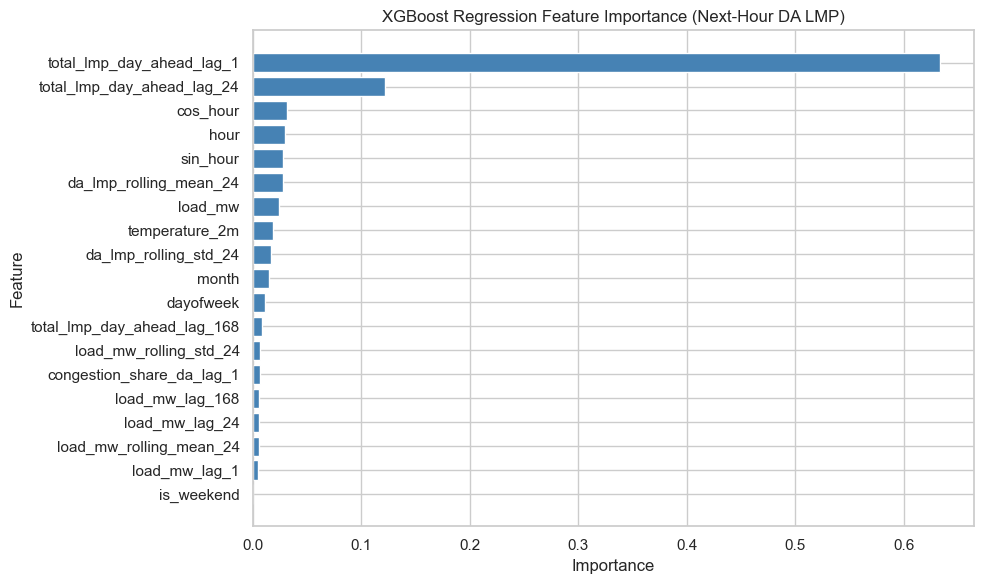

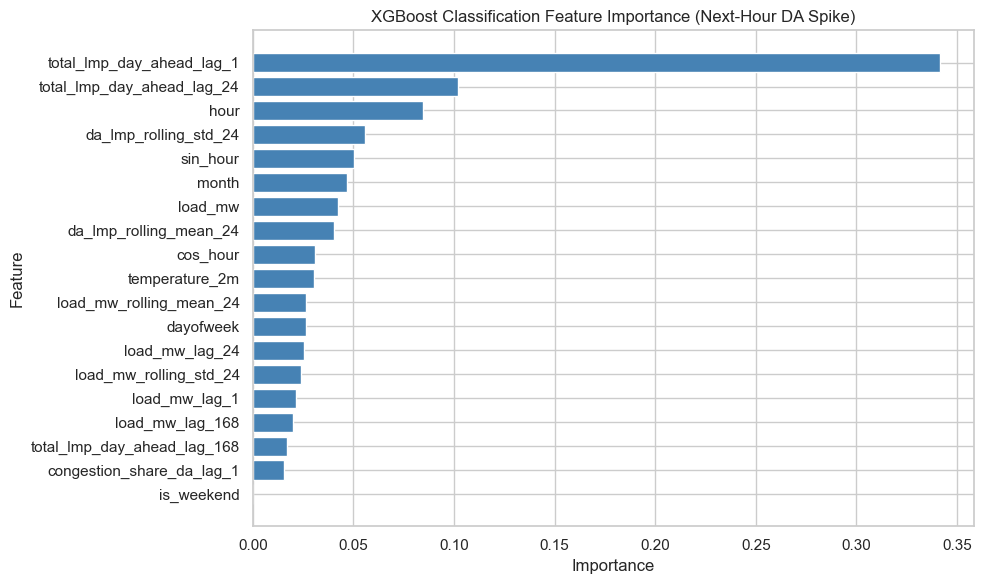

Top XGBoost regression features:
                   feature  importance
 total_lmp_day_ahead_lag_1    0.632885
total_lmp_day_ahead_lag_24    0.122163
                  cos_hour    0.031448
                      hour    0.029359
                  sin_hour    0.027780
    da_lmp_rolling_mean_24    0.027742
                   load_mw    0.024216
            temperature_2m    0.018873
     da_lmp_rolling_std_24    0.016506
                     month    0.015257
Top XGBoost classification features:
                   feature  importance
 total_lmp_day_ahead_lag_1    0.341355
total_lmp_day_ahead_lag_24    0.101728
                      hour    0.084735
     da_lmp_rolling_std_24    0.055727
                  sin_hour    0.050415
                     month    0.046879
                   load_mw    0.042402
    da_lmp_rolling_mean_24    0.040320
                  cos_hour    0.030761
            temperature_2m    0.030321
shap is not installed in this environment. Install shap to generate SHAP

In [111]:
def plot_feature_importance(model, feature_names, title):
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel('Importance')
    ax.set_ylabel('Feature')
    plt.tight_layout()
    plt.show()

plot_feature_importance(reg_model, regression_features, 'XGBoost Regression Feature Importance (Next-Hour DA LMP)')
plot_feature_importance(cls_model, cls_features, 'XGBoost Classification Feature Importance (Next-Hour DA Spike)')

importance_reg = pd.DataFrame({
    'feature': regression_features,
    'importance': reg_model.feature_importances_
}).sort_values('importance', ascending=False)

importance_cls = pd.DataFrame({
    'feature': cls_features,
    'importance': cls_model.feature_importances_
}).sort_values('importance', ascending=False)

print('Top XGBoost regression features:')
print(importance_reg.head(10).to_string(index=False))
print('Top XGBoost classification features:')
print(importance_cls.head(10).to_string(index=False))

try:
    import shap
    explainer = shap.TreeExplainer(reg_model)
    shap_values = explainer.shap_values(X_test_reg)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_reg, feature_names=regression_features, plot_type='bar', show=False)
    plt.title('SHAP Summary - XGBoost Regression (Next-Hour DA LMP)')
    plt.tight_layout()
    plt.show()
except ImportError:
    print('shap is not installed in this environment. Install shap to generate SHAP interpretability outputs.')

## Lag Price Feature Ablation Experiment

Compare the current next-hour DA LMP model against a no-price-lag version to test how much forecast skill comes from recent LMP history. Model A uses the full feature set. Model B removes all features whose names contain `lmp`, following `regression_features_no_lag = [f for f in regression_features if 'lmp' not in f]`.


Removed LMP history features:
['total_lmp_day_ahead_lag_1', 'total_lmp_day_ahead_lag_24', 'total_lmp_day_ahead_lag_168', 'da_lmp_rolling_mean_24', 'da_lmp_rolling_std_24']
Model A feature count: 19
Model B feature count: 14
Ablation metrics:
                             MAE    RMSE  Safe MAPE (abs > 1)  MAE_change_vs_A  MAE_change_vs_A_%
Model A: full features     6.426  10.804               13.124            0.000              0.000
Model B: no LMP features  14.647  19.457               30.748            8.221            127.938
Top Model A regression features:
                   feature  importance
 total_lmp_day_ahead_lag_1    0.632885
total_lmp_day_ahead_lag_24    0.122163
                  cos_hour    0.031448
                      hour    0.029359
                  sin_hour    0.027780
    da_lmp_rolling_mean_24    0.027742
                   load_mw    0.024216
            temperature_2m    0.018873
     da_lmp_rolling_std_24    0.016506
                     month    0.015257
To

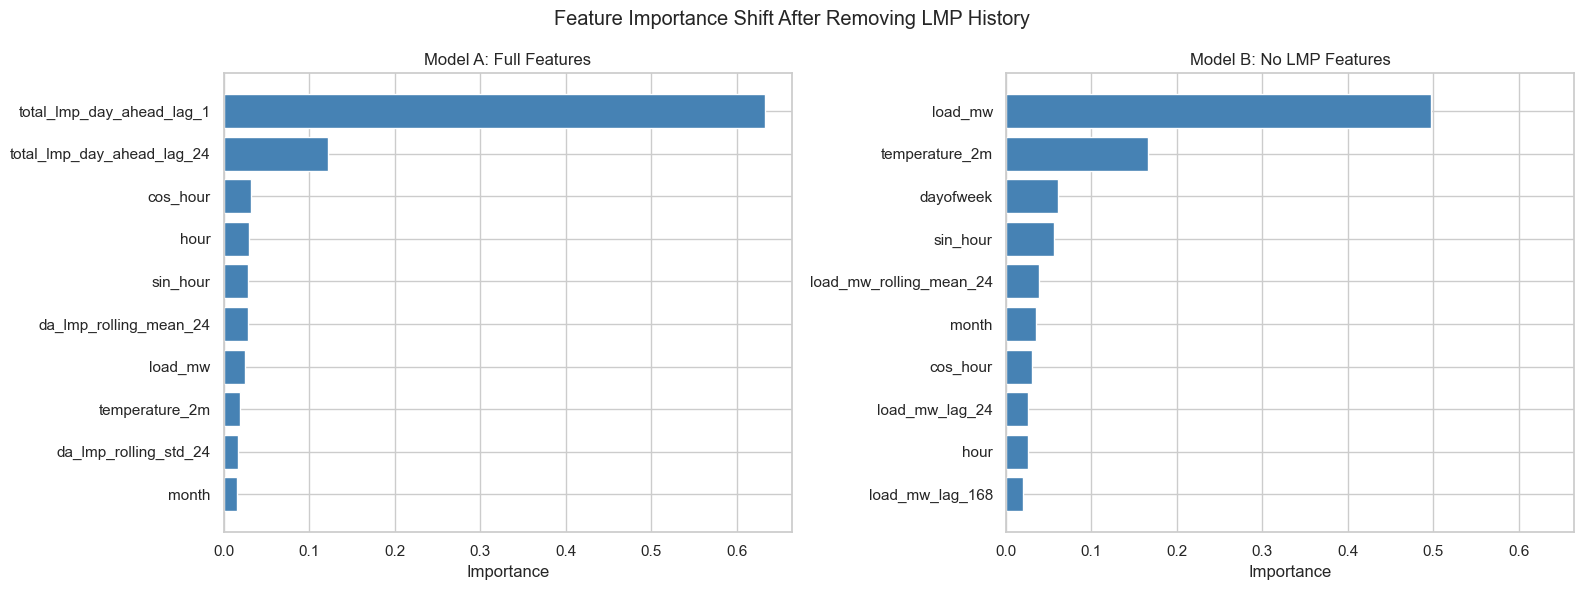

In [112]:
regression_features_no_lag = [f for f in regression_features if 'lmp' not in f]
removed_lmp_features = [f for f in regression_features if f not in regression_features_no_lag]

print('Removed LMP history features:')
print(removed_lmp_features)
print(f'Model A feature count: {len(regression_features)}')
print(f'Model B feature count: {len(regression_features_no_lag)}')

def train_ablation_regressor(features):
    model = XGBRegressor(
        n_estimators=200, learning_rate=0.05, random_state=42, n_jobs=-1, verbosity=0
    )
    model.fit(train_df[features], y_train_reg)
    preds = model.predict(test_df[features])

    mask = np.abs(y_test_reg) > 1
    metrics = {
        'MAE': mean_absolute_error(y_test_reg, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test_reg, preds)),
        'Safe MAPE (abs > 1)': np.mean(np.abs((y_test_reg[mask] - preds[mask]) / y_test_reg[mask])) * 100 if mask.any() else np.nan
    }
    importance = pd.DataFrame({
        'feature': features,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    return model, preds, metrics, importance

model_a, pred_a, metrics_a, importance_a = train_ablation_regressor(regression_features)
model_b, pred_b, metrics_b, importance_b = train_ablation_regressor(regression_features_no_lag)

ablation_metrics = pd.DataFrame([metrics_a, metrics_b], index=['Model A: full features', 'Model B: no LMP features'])
ablation_metrics['MAE_change_vs_A'] = ablation_metrics['MAE'] - ablation_metrics.loc['Model A: full features', 'MAE']
ablation_metrics['MAE_change_vs_A_%'] = (
    ablation_metrics['MAE'] / ablation_metrics.loc['Model A: full features', 'MAE'] - 1
) * 100

print('Ablation metrics:')
print(ablation_metrics.round(3).to_string())

print('Top Model A regression features:')
print(importance_a.head(10).to_string(index=False))
print('Top Model B regression features:')
print(importance_b.head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
for ax, importance_df, title in [
    (axes[0], importance_a.head(10), 'Model A: Full Features'),
    (axes[1], importance_b.head(10), 'Model B: No LMP Features')
]:
    ax.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel('Importance')

fig.suptitle('Feature Importance Shift After Removing LMP History')
plt.tight_layout()
plt.show()


## Diagnostics

Visualize model performance, next-hour spike prediction behavior, load-LMP relationships, hourly price profiles, and congestion component dynamics. These charts are designed for practical market monitoring and decision support.

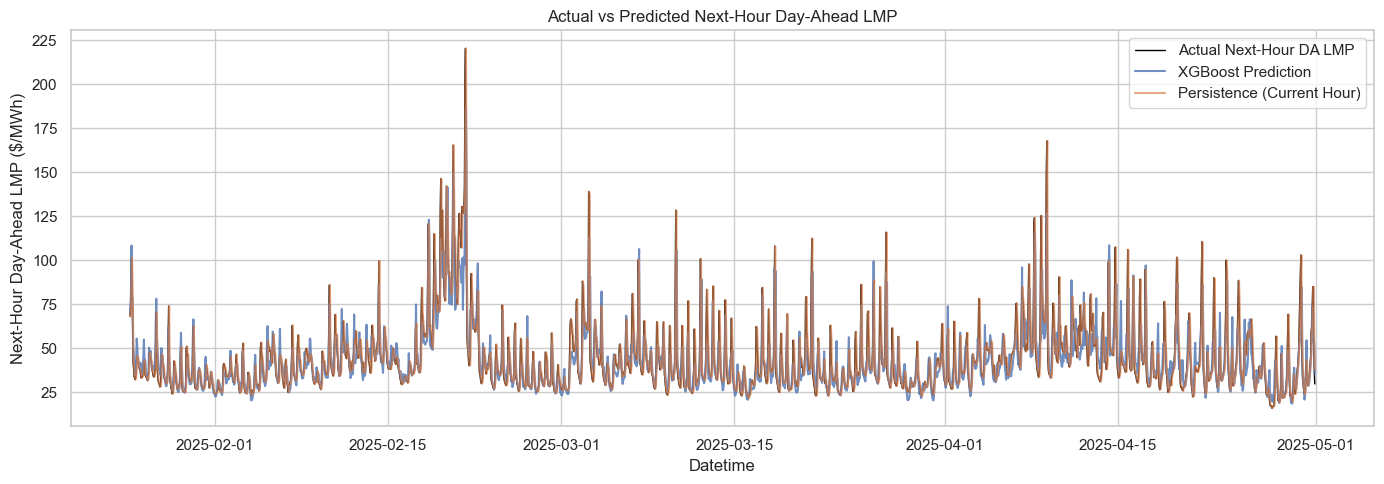

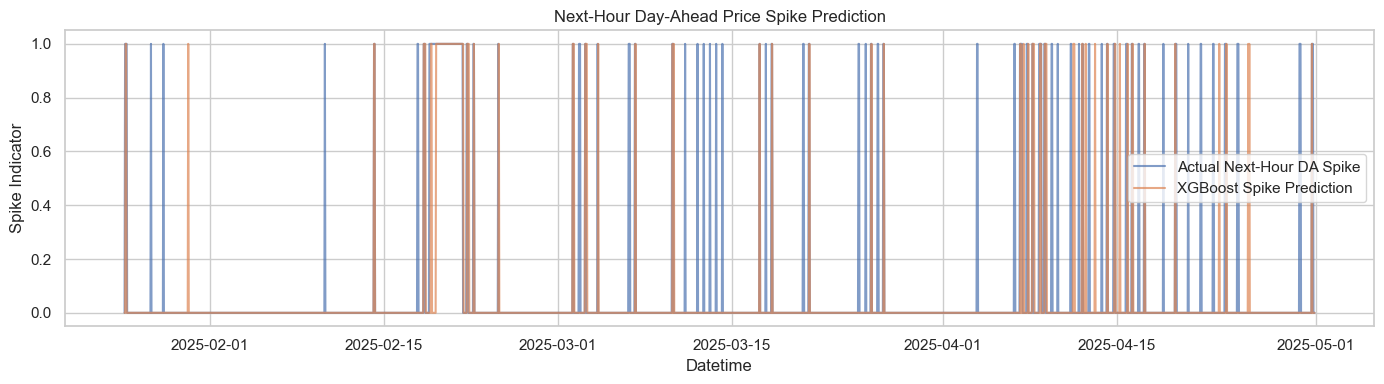

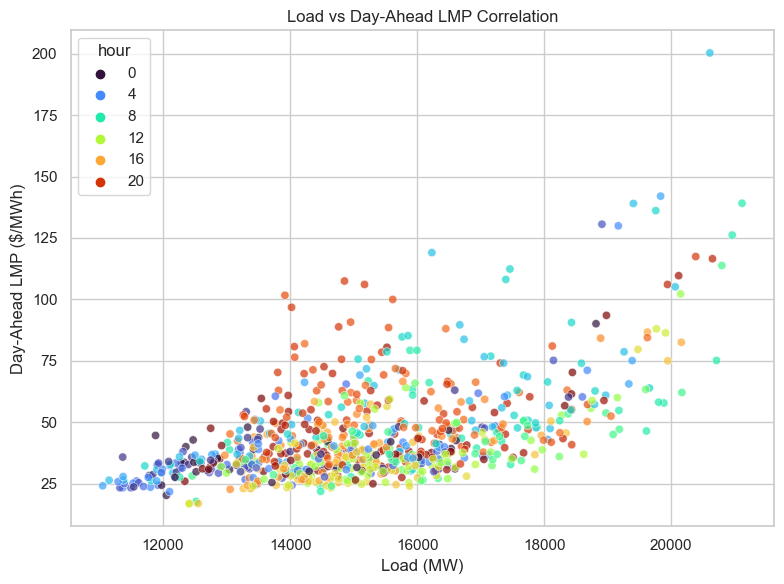

/Users/wangzhuoran/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/wangzhuoran/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


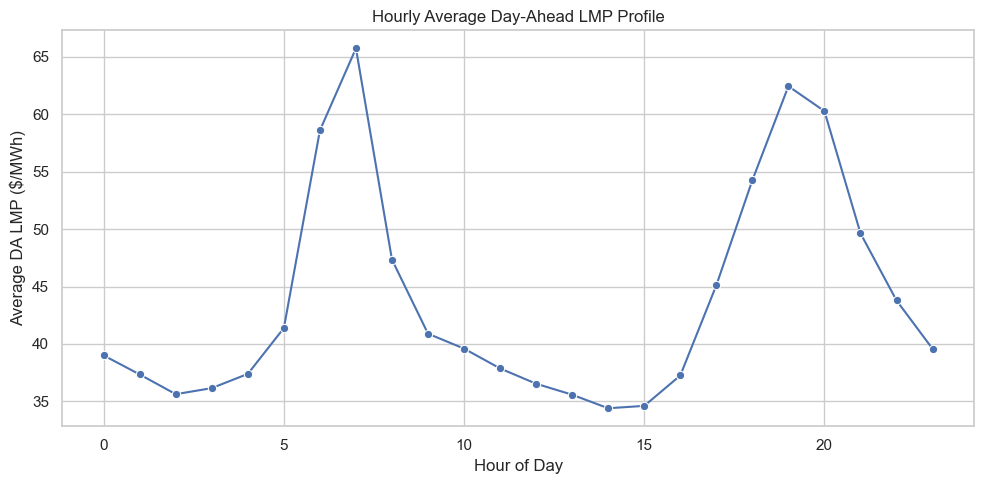

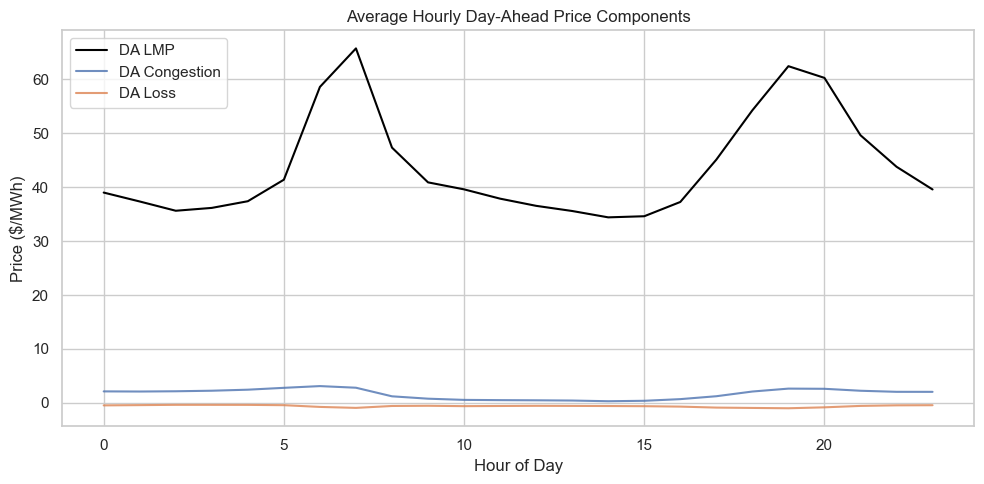

In [113]:
visual_df = test_df[['datetime', 'target_da_lmp_next_hour']].copy()
visual_df = visual_df.rename(columns={'target_da_lmp_next_hour': 'Actual_Next_Hour_DA_LMP'})
visual_df['XGBoost_Prediction'] = y_pred_reg
visual_df['Persistence'] = test_df['total_lmp_day_ahead']  # Use current hour DA LMP as persistence baseline for next-hour prediction

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(visual_df['datetime'], visual_df['Actual_Next_Hour_DA_LMP'], label='Actual Next-Hour DA LMP', color='black', linewidth=1)
ax.plot(visual_df['datetime'], visual_df['XGBoost_Prediction'], label='XGBoost Prediction', alpha=0.8)
ax.plot(visual_df['datetime'], visual_df['Persistence'], label='Persistence (Current Hour)', alpha=0.7)
ax.set_title('Actual vs Predicted Next-Hour Day-Ahead LMP')
ax.set_xlabel('Datetime')
ax.set_ylabel('Next-Hour Day-Ahead LMP ($/MWh)')
ax.legend()
plt.tight_layout()
plt.show()

spike_df = test_df[['datetime', 'target_da_spike_next_hour']].copy()
spike_df['Prediction'] = y_pred_cls
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(spike_df['datetime'], spike_df['target_da_spike_next_hour'], label='Actual Next-Hour DA Spike', alpha=0.7)
ax.plot(spike_df['datetime'], spike_df['Prediction'], label='XGBoost Spike Prediction', alpha=0.7)
ax.set_title('Next-Hour Day-Ahead Price Spike Prediction')
ax.set_xlabel('Datetime')
ax.set_ylabel('Spike Indicator')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    x='load_mw',
    y='total_lmp_day_ahead',
    hue='hour',
    palette='turbo',
    data=test_df.sample(n=min(800, len(test_df)), random_state=42),
    alpha=0.7,
    ax=ax
)
ax.set_title('Load vs Day-Ahead LMP Correlation')
ax.set_xlabel('Load (MW)')
ax.set_ylabel('Day-Ahead LMP ($/MWh)')
plt.tight_layout()
plt.show()

hourly_profile = test_df.groupby('hour')['total_lmp_day_ahead'].mean().reset_index()
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=hourly_profile, x='hour', y='total_lmp_day_ahead', marker='o', ax=ax)
ax.set_title('Hourly Average Day-Ahead LMP Profile')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average DA LMP ($/MWh)')
plt.tight_layout()
plt.show()

congestion_profile = test_df.groupby('hour')[['congestion_price_day_ahead', 'marginal_loss_price_day_ahead', 'total_lmp_day_ahead']].mean().reset_index()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(congestion_profile['hour'], congestion_profile['total_lmp_day_ahead'], label='DA LMP', color='black')
ax.plot(congestion_profile['hour'], congestion_profile['congestion_price_day_ahead'], label='DA Congestion', alpha=0.8)
ax.plot(congestion_profile['hour'], congestion_profile['marginal_loss_price_day_ahead'], label='DA Loss', alpha=0.8)
ax.set_title('Average Hourly Day-Ahead Price Components')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Price ($/MWh)')
ax.legend()
plt.tight_layout()
plt.show()

## Spike Timing and Load Analysis

Analyze when day-ahead price spikes occur in the held-out test period and whether they cluster at higher load levels.

DA price spike count by hour in test set:
hour
0      4
1      3
2      3
3      3
4      3
5      5
6     24
7     32
8      8
9      5
10     3
11     2
12     2
13     2
14     2
15     2
16     2
17     4
18    12
19    30
20    25
21     7
22     4
23     4
Name: count, dtype: int64


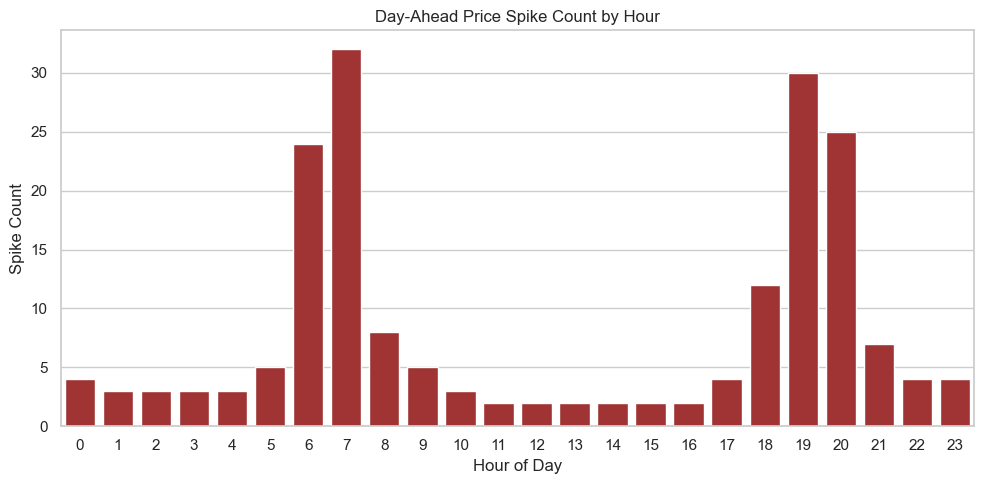

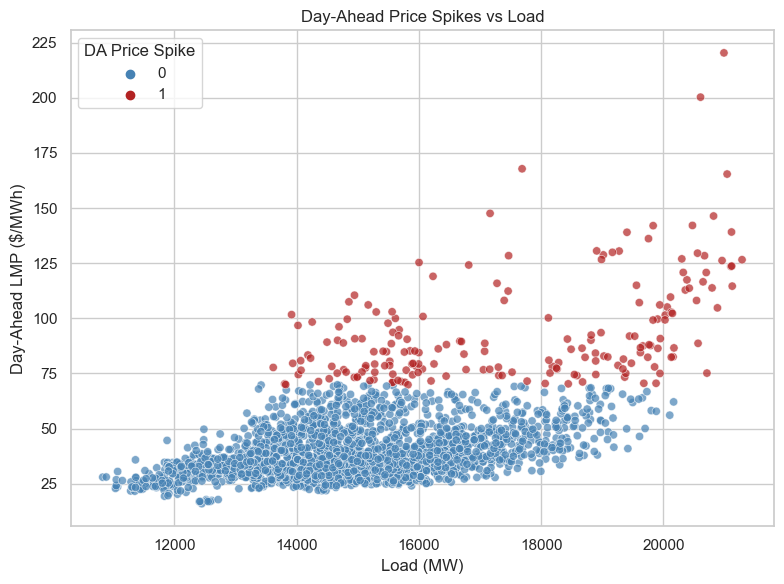

In [114]:
spike_hours = test_df[test_df['da_price_spike'] == 1]

print('DA price spike count by hour in test set:')
print(spike_hours['hour'].value_counts().sort_index())

spike_hour_counts = (
    spike_hours['hour']
    .value_counts()
    .sort_index()
    .reindex(range(24), fill_value=0)
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=spike_hour_counts.index, y=spike_hour_counts.values, color='firebrick', ax=ax)
ax.set_title('Day-Ahead Price Spike Count by Hour')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Spike Count')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=test_df,
    x='load_mw',
    y='total_lmp_day_ahead',
    hue='da_price_spike',
    palette={0: 'steelblue', 1: 'firebrick'},
    alpha=0.7,
    ax=ax
)
ax.set_title('Day-Ahead Price Spikes vs Load')
ax.set_xlabel('Load (MW)')
ax.set_ylabel('Day-Ahead LMP ($/MWh)')
ax.legend(title='DA Price Spike')
plt.tight_layout()
plt.show()


## Simple Trading Signal

Build a lightweight spread signal from the day-ahead and real-time price relationship. Spread signals can be used to identify short-term arbitrage or hedging opportunities.

Spread signal threshold (90th percentile absolute spread): 23.77 $/MWh
Signal direction counts:
signal_direction
Neutral                            2069
RT premium / potential DA hedge     143
DA premium / potential RT hedge      87
Largest absolute spread signals:
           datetime  hour  total_lmp_day_ahead  total_lmp_real_time  spread_signal  pred_spread   load_mw                signal_direction
2025-04-08 07:00:00     7           124.197304           918.578577     794.381273    -8.112595 16815.879 RT premium / potential DA hedge
2025-02-05 10:00:00    10            50.727441           297.504302     246.776861    -8.940427 17529.897 RT premium / potential DA hedge
2025-04-23 16:00:00    16            41.616604           210.177489     168.560885    12.276153 15406.405 RT premium / potential DA hedge
2025-02-06 10:00:00    10            41.742762           162.891866     121.149104    -0.157660 17279.206 RT premium / potential DA hedge
2025-02-11 09:00:00     9            53.7756

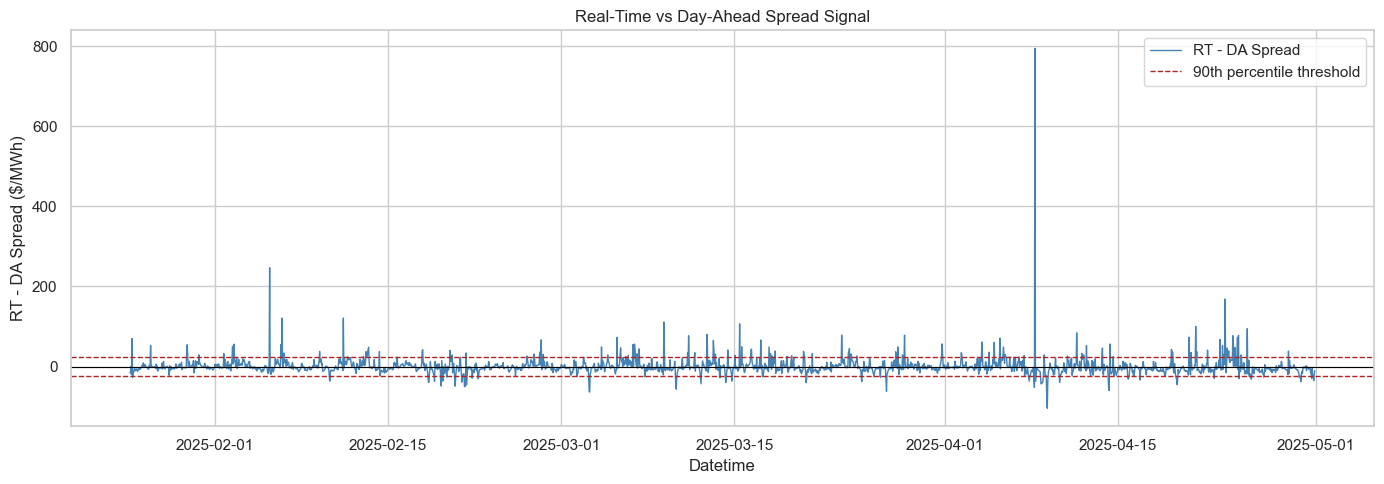

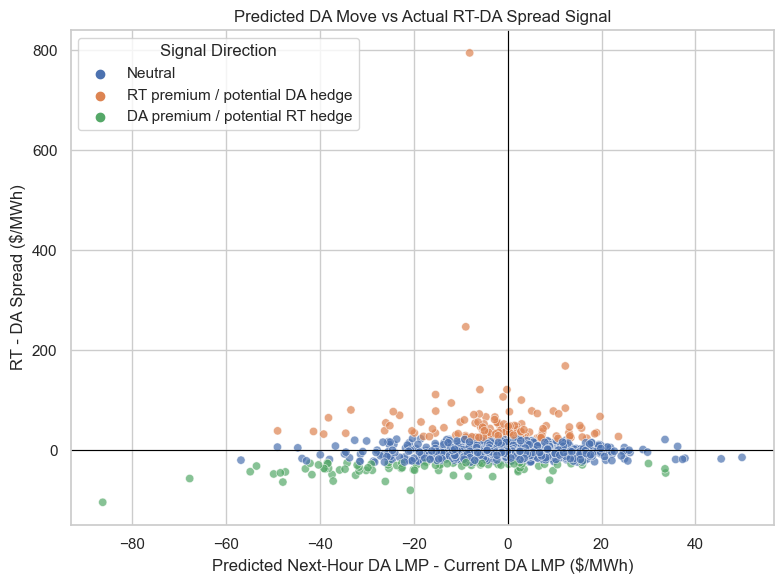

In [115]:
signal_df = test_df[['datetime', 'hour', 'total_lmp_day_ahead', 'total_lmp_real_time', 'rt_da_spread', 'load_mw']].copy()
signal_df['pred_next_hour_da_lmp'] = y_pred_reg
signal_df['pred_spread'] = signal_df['pred_next_hour_da_lmp'] - signal_df['total_lmp_day_ahead']
signal_df['spread_signal'] = signal_df['rt_da_spread']

spread_threshold = signal_df['spread_signal'].abs().quantile(0.90)
signal_df['signal_direction'] = np.select(
    [
        signal_df['spread_signal'] >= spread_threshold,
        signal_df['spread_signal'] <= -spread_threshold
    ],
    ['RT premium / potential DA hedge', 'DA premium / potential RT hedge'],
    default='Neutral'
)

print(f'Spread signal threshold (90th percentile absolute spread): {spread_threshold:.2f} $/MWh')
print('Signal direction counts:')
print(signal_df['signal_direction'].value_counts().to_string())

print('Largest absolute spread signals:')
print(
    signal_df.assign(abs_spread_signal=signal_df['spread_signal'].abs())
    .sort_values('abs_spread_signal', ascending=False)
    [['datetime', 'hour', 'total_lmp_day_ahead', 'total_lmp_real_time', 'spread_signal', 'pred_spread', 'load_mw', 'signal_direction']]
    .head(10)
    .to_string(index=False)
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(signal_df['datetime'], signal_df['spread_signal'], label='RT - DA Spread', color='steelblue', linewidth=1)
ax.axhline(spread_threshold, color='firebrick', linestyle='--', linewidth=1, label='90th percentile threshold')
ax.axhline(-spread_threshold, color='firebrick', linestyle='--', linewidth=1)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Real-Time vs Day-Ahead Spread Signal')
ax.set_xlabel('Datetime')
ax.set_ylabel('RT - DA Spread ($/MWh)')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=signal_df,
    x='pred_spread',
    y='spread_signal',
    hue='signal_direction',
    alpha=0.7,
    ax=ax
)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Predicted DA Move vs Actual RT-DA Spread Signal')
ax.set_xlabel('Predicted Next-Hour DA LMP - Current DA LMP ($/MWh)')
ax.set_ylabel('RT - DA Spread ($/MWh)')
ax.legend(title='Signal Direction')
plt.tight_layout()
plt.show()


## Market Interpretation

The analysis shows that next-hour day-ahead LMP is primarily driven by its own recent history, with strong lag-1 and lag-24 effects indicating both short-term persistence and daily seasonality in electricity prices.

Peak pricing is consistently concentrated in late afternoon and early evening hours, reflecting demand ramps and tighter system conditions during peak load periods. This pattern is reinforced by the hourly LMP profile, which shows clear dual-peak behavior aligned with operational demand cycles.

While load and temperature contribute to price formation, their marginal impact is secondary relative to lagged price signals, suggesting that much of the fundamental information is already embedded in recent market outcomes. However, at higher load levels, price dispersion increases significantly, indicating elevated volatility and higher spike risk.

The day-ahead versus real-time spread highlights periods of market imbalance, where real-time prices deviate sharply due to unexpected demand shifts, congestion, or operational constraints. These spread spikes tend to cluster in high-volatility regimes, making them particularly relevant for short-term trading and hedging strategies.

Feature importance from the XGBoost models confirms that time-of-day structure, lagged price dynamics, and short-term volatility are the dominant drivers of both price level and spike risk. For spike prediction, volatility and temporal features play a larger role, indicating that extreme price events are associated with system stress rather than average conditions.

From an operational perspective, this workflow supports identifying high-risk pricing windows, monitoring short-term exposure during volatile periods, and understanding when market conditions deviate from typical patterns. The integration of load, weather, and price signals provides a practical foundation for short-horizon forecasting and decision support.

Overall, this notebook reflects a structured, industry-style market analytics pipeline, combining clean data engineering, leakage-safe feature construction, and interpretable machine learning models to produce actionable insights for energy market operations.

The lag-price ablation experiment makes this dependence explicit: removing LMP history increases next-hour DA LMP MAE substantially, while feature importance shifts toward load, temperature, and calendar structure. This confirms that the full model is highly accurate largely because it captures market price persistence, whereas the no-LMP model is a more fundamentals-driven but less precise benchmark.
